# Система рекомендаций фильмов

Импортируем библиотеки и модули

In [ ]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
from scipy.sparse import csr_matrix
from fuzzywuzzy import process
from sklearn.neighbors import NearestNeighbors

In [ ]:
!pip install fuzzywuzzy python-Levenshtein

# Загружаем необходимые данные в качестве dataseta будем использовать публичный датасет из MovieLeens dataset

In [ ]:
useful_columns = ['movieId', 'title', 'genres']

# Читаем только нужные столбцы с chunksize
for chunk in pd.read_csv('/content/drive/MyDrive/content/movie.csv', usecols=useful_columns, chunksize=8192):
    # Обрабатываем и используем каждый блок
    pass

In [ ]:
useful_columns = ['userId', 'movieId', 'rating']

# Читаем только нужные столбцы с chunksize
for chunk in pd.read_csv('/content/drive/MyDrive/content/rating.csv', usecols=useful_columns, chunksize=8192):
    # Обрабатываем и используем каждый блок
    pass

In [ ]:
#@title Анализ датасета movie.csv
df = pd.read_csv('/content/drive/MyDrive/content/movie.csv', sep=',')
df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
#@title Выводим название всех столбцов DataFrame
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB


In [ ]:
#@title Проверяем наличие дубликатов строк в DataFrame и суммируем их количество.
# df.duplicated() возвращает Series булевых значений, где True означает дублирующуюся строку.
# .sum() подсчитывает количество True значений (то есть количество дубликатов).
df.duplicated().sum()

np.int64(0)

In [ ]:
#@title Анализ датасета rating.csv
df = pd.read_csv('/content/drive/MyDrive/content/rating.csv', sep=',')
df.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [ ]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 610.4+ MB


In [ ]:
#@title создаем dataframe movies_df
movies_df = pd.read_csv('/content/drive/MyDrive/content/movie.csv', sep=',')

In [ ]:
#@title создаем dataframe ratings_df
ratings_df = pd.read_csv('/content/drive/MyDrive/content/rating.csv', sep=',')

In [ ]:
#@title объединяем созданые фреймы данных по общему столбцу movieId
merged_df = pd.merge(ratings_df, movies_df, on='movieId', how='inner')
print(merged_df.head())

   userId  movieId  rating                                              title  \
0       1        2     3.5                                     Jumanji (1995)   
1       1       29     3.5  City of Lost Children, The (Cité des enfants p...   
2       1       32     3.5          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   
3       1       47     3.5                        Seven (a.k.a. Se7en) (1995)   
4       1       50     3.5                         Usual Suspects, The (1995)   

                                   genres  
0              Adventure|Children|Fantasy  
1  Adventure|Drama|Fantasy|Mystery|Sci-Fi  
2                 Mystery|Sci-Fi|Thriller  
3                        Mystery|Thriller  
4                  Crime|Mystery|Thriller  


In [ ]:
#@title удаляем лишний столбец timestamp
ratings_df = ratings_df.drop('timestamp', axis=1)
ratings_df.head()

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


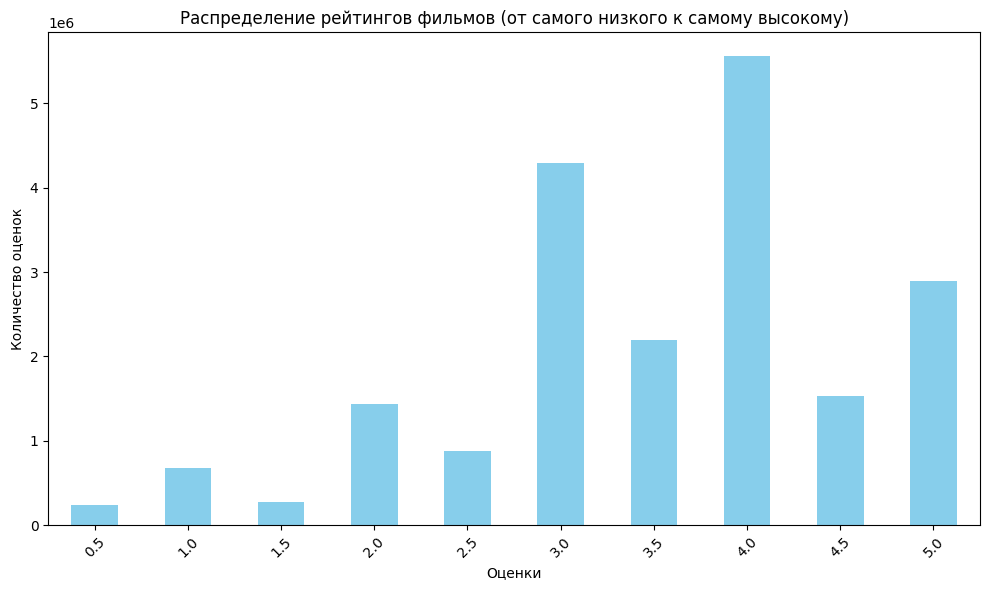

In [ ]:
import matplotlib.pyplot as plt

#@title Строим график по фрейму ratings_df для распределения оценок пользователей
# Сгруппируем по рейтингу и подсчитайте количество вхождений, затем отсортируем по значению рейтинга
rating_counts = ratings_df['rating'].value_counts().sort_index()

# Создаем столбчатую диаграмму
plt.figure(figsize=(10, 6))
rating_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Оценки')
plt.ylabel('Количество оценок')
plt.title('Распределение рейтингов фильмов (от самого низкого к самому высокому)')
plt.xticks(rotation=45) # Поворачиваем надписи по оси x для лучшей читаемости
plt.tight_layout()
plt.show()

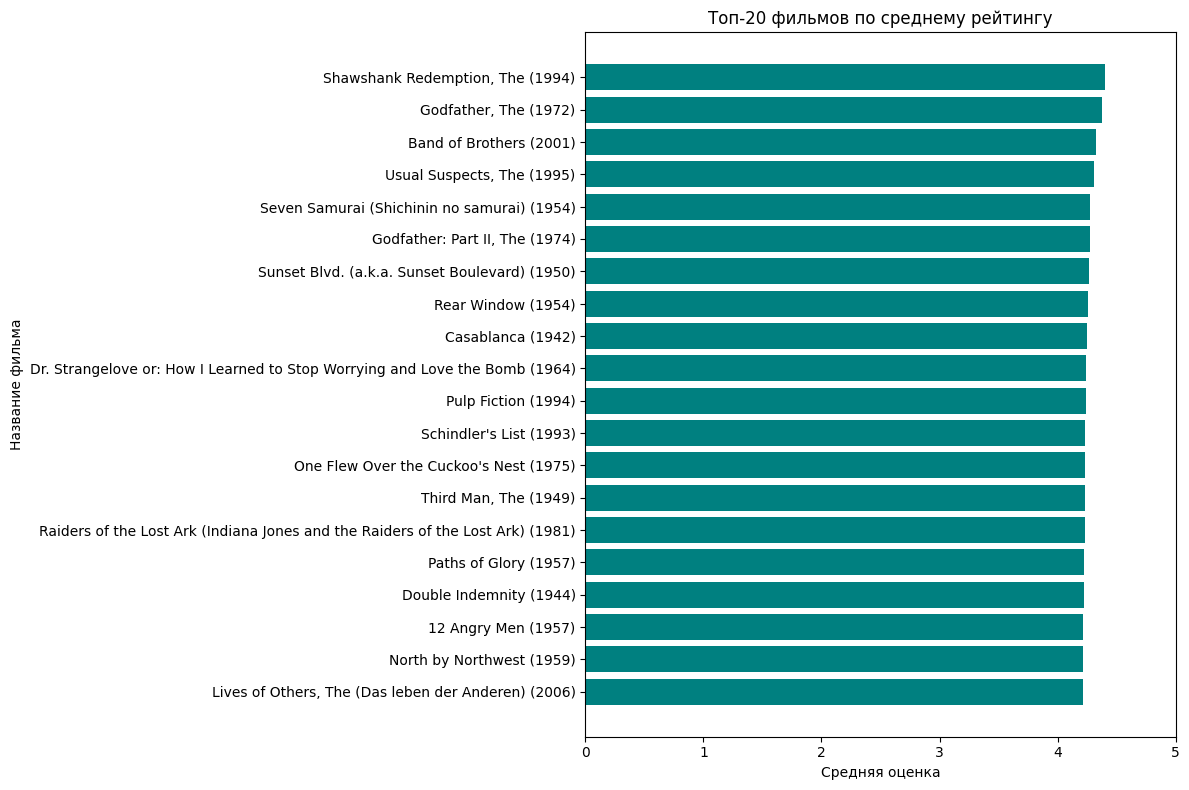

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

#@title Строим график по фрейму movies_df для определения топ лучших фильмов по среднему рейтингу
# Объединяем movies_df с average_movie_ratings, чтобы получить названия и средние оценки
top_movies_df = pd.merge(movies_df, average_movie_ratings, on='movieId', how='inner')

# Отсортируем по среднему рейтингу в порядке убывания и выберим N лучших фильмов
top_n = 20
top_movies_df = top_movies_df.sort_values(by='average_rating', ascending=False).head(top_n)

# Создаем горизонтальную линейчатую диаграмму
plt.figure(figsize=(12, 8))
plt.barh(top_movies_df['title'], top_movies_df['average_rating'], color='teal')
plt.xlabel('Средняя оценка')
plt.ylabel('Название фильма')
plt.title(f'Топ-20 фильмов по среднему рейтингу')
plt.xlim(0, 5) # Предполагаем, что оценки даны по шкале от 0 до 5
plt.gca().invert_yaxis() # Перевернем ось y, чтобы получить самый высокий рейтинг вверху
plt.tight_layout()
plt.show()

## Обработка жанров и объединение с рейтингами

Разделим столбец 'genres' в `movies_df` на отдельные жанры, а затем объединим эти данные с `ratings_df` для получения оценок по каждому жанру.


In [ ]:
movies_df['genres'] = movies_df['genres'].apply(lambda x: x.split('|'))
print("Разделение столбца 'genres' на списки жанров.")
print(movies_df.head())

Разделение столбца 'genres' на списки жанров.
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                              genres  
0  [Adventure, Animation, Children, Comedy, Fantasy]  
1                     [Adventure, Children, Fantasy]  
2                                  [Comedy, Romance]  
3                           [Comedy, Drama, Romance]  
4                                           [Comedy]  


In [ ]:
movies_exploded_df = movies_df.explode('genres')
print("Столбец 'genres' был разделен на отдельные записи.")
print(movies_exploded_df.head())

Столбец 'genres' был разделен на отдельные записи.
   movieId             title     genres
0        1  Toy Story (1995)  Adventure
0        1  Toy Story (1995)  Animation
0        1  Toy Story (1995)   Children
0        1  Toy Story (1995)     Comedy
0        1  Toy Story (1995)    Fantasy


In [ ]:
ratings_with_genres = pd.merge(ratings_df, movies_exploded_df, on='movieId', how='inner')
print("Объединение ratings_df с movies_exploded_df завершено.")
print(ratings_with_genres.head())

Объединение ratings_df с movies_exploded_df завершено.
   userId  movieId  rating                                              title  \
0       1        2     3.5                                     Jumanji (1995)   
1       1        2     3.5                                     Jumanji (1995)   
2       1        2     3.5                                     Jumanji (1995)   
3       1       29     3.5  City of Lost Children, The (Cité des enfants p...   
4       1       29     3.5  City of Lost Children, The (Cité des enfants p...   

      genres  
0  Adventure  
1   Children  
2    Fantasy  
3  Adventure  
4      Drama  


In [ ]:
average_ratings_by_genre = ratings_with_genres.groupby('genres')['rating'].mean().reset_index()
print("Расчет средних оценок для каждого жанра завершен.")
print(average_ratings_by_genre.head())

Расчет средних оценок для каждого жанра завершен.
               genres    rating
0  (no genres listed)  3.006925
1              Action  3.443864
2           Adventure  3.501893
3           Animation  3.617494
4            Children  3.408114


In [ ]:
top_n = 10 # Define N for top genres
sorted_genres = average_ratings_by_genre.sort_values(by='rating', ascending=False).head(top_n)
print("Топ-N жанров по среднему рейтингу:")
print(sorted_genres)

Топ-N жанров по среднему рейтингу:
         genres    rating
10    Film-Noir  3.965381
18          War  3.809531
7   Documentary  3.739718
6         Crime  3.674528
8         Drama  3.674296
14      Mystery  3.663509
12         IMAX  3.655946
3     Animation  3.617494
19      Western  3.570498
13      Musical  3.558091


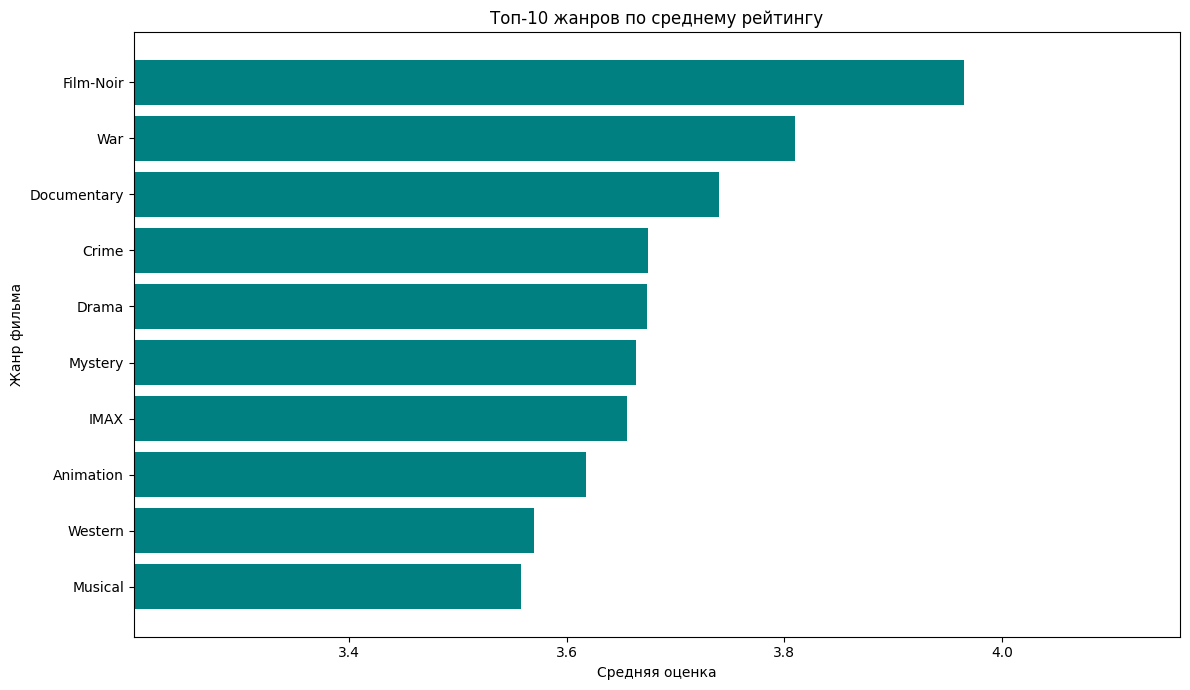

In [ ]:
import matplotlib.pyplot as plt
#@title Строим график на основе фрейма movies_df чтобы определить топ жанров со средней оценкой пользователей
# Построение горизонтальной столбчатой диаграммы
plt.figure(figsize=(12, 7))
plt.barh(sorted_genres['genres'], sorted_genres['rating'], color='teal')
plt.xlabel('Средняя оценка')
plt.ylabel('Жанр фильма')
plt.title(f'Топ 10 жанров по среднему рейтингу')    # Настройка пределов для оси X
# Левый предел: минимальная оценка * 0.9 (чтобы столбцы не начинались прямо от края)
# Правый предел: максимальная оценка * 1.05 (чтобы обеспечить небольшой отступ после самого длинного столбца)
plt.xlim(sorted_genres['rating'].min() * 0.9, sorted_genres['rating'].max() * 1.05) # Динамическая подстройка пределов оси x
plt.gca().invert_yaxis() # Инвертирование оси Y
# Это делается для того, чтобы жанр с самой высокой средней оценкой отображался сверху
plt.tight_layout()
plt.show()


In [ ]:
#@title создаем матрицу пользовательских запросов
min_user_ratings = 200
min_movie_ratings = 200

# Подсчитываем оценки каждого пользователя и фильтруем пользователей
user_counts = ratings_df['userId'].value_counts()
filtered_users = user_counts[user_counts >= min_user_ratings].index
filtered_ratings = ratings_df[ratings_df['userId'].isin(filtered_users)]

# Подсчитываем оценки для каждого фильма и фильтруем фильмы
movie_counts = filtered_ratings['movieId'].value_counts()
filtered_movies = movie_counts[movie_counts >= min_movie_ratings].index
filtered_ratings = filtered_ratings[filtered_ratings['movieId'].isin(filtered_movies)]

# Подсчитываем средние оценки для каждого фильма и фильтруем оценки
average_movie_ratings = filtered_ratings.groupby('movieId')['rating'].mean().reset_index()
average_movie_ratings.columns = ['movieId', 'average_rating']


print(f"Original ratings: {len(ratings_df)}")
print(f"Filtered ratings: {len(filtered_ratings)}")

# Повторно запускаем создание матрицы
pivoted_df = filtered_ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Создаем матрицу "элемент-пользователь" для рекомендаций "элемент-товар"
# Фильмы будут строками, пользователи - столбцами
item_user_matrix = csr_matrix(pivoted_df.T.values)

# Получаем список идентификаторов фильмов, которые на самом деле находятся в столбцах
matrix_movie_ids = pivoted_df.columns.tolist()

Original ratings: 20000263
Filtered ratings: 11905303


In [ ]:
#@title обучаем модель на основе алгоритма K ближайших соседей KNN
# Определяем модель KNN на основе косинусоидального подобия
cf_knn_model= NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10, n_jobs=-1)


# Подгонка модели по нашей матрице "товар-пользователь"
cf_knn_model.fit(item_user_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1, n_neighbors=10)

In [ ]:
#@title создаем функцию рекомендаций фильмов на основе модели KNN
def movie_recommender_engine(movie_name, matrix, cf_model, n_recs, movies_df, matrix_movie_ids, average_movie_ratings):
    # 1. Нечеткое сопоставление movie_name для получения исходного идентификатора фильма из movies_df
    all_known_movie_titles = movies_df['title'].tolist()

    # extractOne возвращает (best_match_title, оценка). Индекс не возвращается.
    best_match_title, score = process.extractOne(movie_name, all_known_movie_titles)

    # Получим исходный индекс из movies_df для соответствующего названия
    # индекс[0] используется для получения фактического целочисленного индекса из объекта Index
    movies_df_index = movies_df[movies_df['title'] == best_match_title].index[0]

    # Получим исходный идентификатор фильма из movies_df, используя найденный индекс
    original_movie_id = movies_df.loc[movies_df_index, 'movieId']

    # Проверяем, присутствует ли этот original_movie_id в нашей отфильтрованной матрице
    if original_movie_id not in matrix_movie_ids:
        print(f"Movie '{best_match_title}' (ID: {original_movie_id}) not found in the filtered rating matrix. Cannot recommend.")
        return pd.DataFrame()

    # 2. Сопоставляем original_movie_id с внутренним индексом user_item_matrix
    #    Внутренний индекс - это позиция original_movie_id в списке matrix_movie_ids
    movie_matrix_index = matrix_movie_ids.index(original_movie_id)

    # 3. Рассчитываем расстояния между соседями, используя модель коллаборативной фильтрации
    #    "матрица" здесь означает "item_user_matrix", которая содержит данные о рейтинге пользователя.
    #    "cf_model" - это модель NearestNeighbors, обученная на основе этой "item_user_матрицы"
    #    позволяющая находить фильмы с похожими шаблонами оценки пользователями.
    #    Запрашивая 'matrix[movie_matrix_index]', мы получаем вектор рейтинга для входного фильма,
    #    а 'cf_model' находит другие фильмы, которые пользователи оценили аналогичным образом.
    distances, indices = cf_model.kneighbors(matrix[movie_matrix_index], n_neighbors=n_recs + 1) # +1, чтобы исключить сам фильм

    # movie_rec_ids будет хранить пары (internal_matrix_index, расстояние)
    # Исключаем первый, который является самим фильмом (расстояние 0).
    movie_rec_ids = sorted(list(zip(indices.squeeze().tolist(), distances.squeeze().tolist())), key=lambda x: x[1])[1:]

    # Список для хранения рекомендаций
    cf_recs = []
    for i_matrix, dist in movie_rec_ids:
        # Преобразовываем internal_matrix_index обратно в исходный идентификатор фильма
        rec_original_movie_id = matrix_movie_ids[i_matrix]
        # Получаем название, используя оригинальный идентификатор фильма из movies_df
        rec_title = movies_df[movies_df['movieId'] == rec_original_movie_id]['title'].iloc[0]

        # Получаем среднюю оценку рекомендуемого фильма
        avg_rating_row = average_movie_ratings[average_movie_ratings['movieId'] == rec_original_movie_id]
        avg_rating = avg_rating_row['average_rating'].iloc[0] if not avg_rating_row.empty else None

        cf_recs.append({'Title': rec_title, 'Distance': dist, 'Average_Rating': avg_rating})

    # Выбераем максимальное количество необходимых рекомендаций
    df_recs = pd.DataFrame(cf_recs)
    return df_recs

In [ ]:
#@title Получаем рекомендацию от модели по фильму Аватар
n_recs = 10
recommended_movies_matrix = movie_recommender_engine('Avatar', item_user_matrix, cf_knn_model, n_recs, movies_df, matrix_movie_ids, average_movie_ratings)
print("\nРекомендации для фильма Аватар, основанные на оценках пользователей (коллаборативная фильтрация):")
# Отображение столбцов "Расстояние" и "Средняя оценка", отформатированных с точностью до двух знаков после запятой
if 'Average_Rating' in recommended_movies_matrix.columns:
    print(recommended_movies_matrix[['Title', 'Distance', 'Average_Rating']].round(2))
else:
    print(recommended_movies_matrix[['Title', 'Distance']].round(2))


Рекомендации для фильма Аватар, основанные на оценках пользователей (коллаборативная фильтрация):
                         Title  Distance  Average_Rating
0             Inception (2010)      0.26            4.11
1            District 9 (2009)      0.31            3.85
2      Dark Knight, The (2008)      0.31            4.17
3              Iron Man (2008)      0.33            3.85
4                    Up (2009)      0.33            3.98
5  Inglourious Basterds (2009)      0.33            3.97
6             Star Trek (2009)      0.33            3.89
7                WALL·E (2008)      0.34            4.02
8       Sherlock Holmes (2009)      0.35            3.67
9         Hangover, The (2009)      0.35            3.67


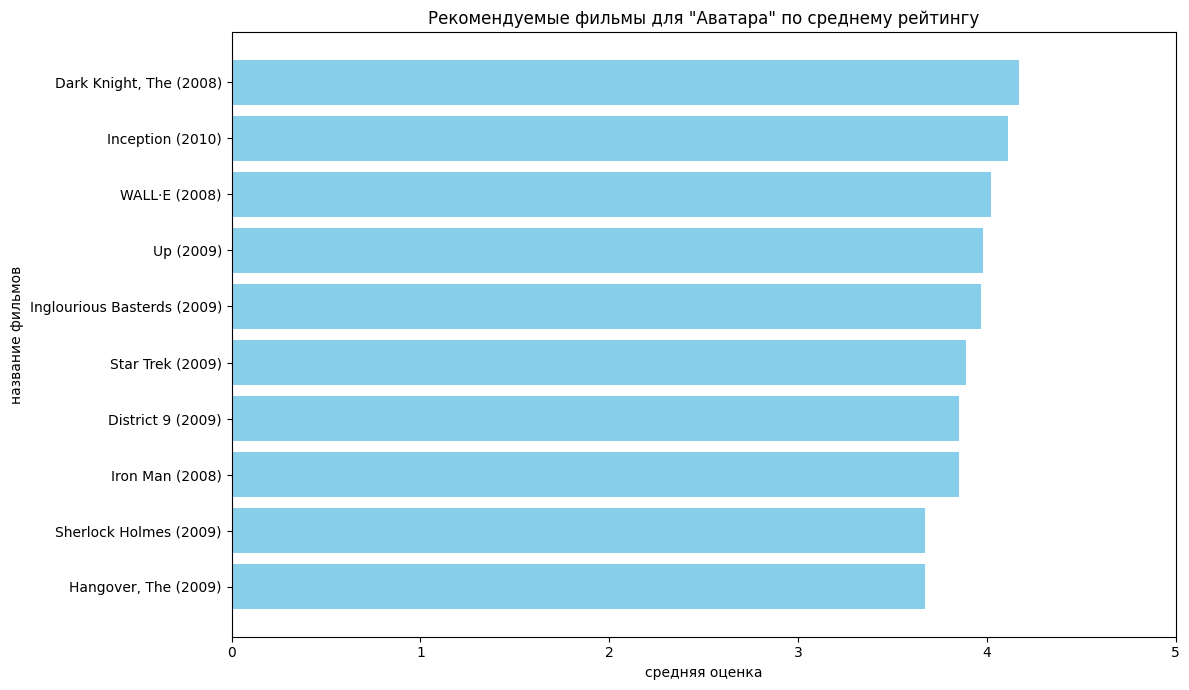

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

#@title Строим столбчатую диаграму на основе выходных данных по рекомендаций модели по фильму Аватар
# Данные, предоставленные пользователем
data_avatar = {
    'Title': [
        'Inception (2010)', 'District 9 (2009)', 'Dark Knight, The (2008)',
        'Iron Man (2008)', 'Up (2009)', 'Inglourious Basterds (2009)',
        'Star Trek (2009)', 'WALL·E (2008)', 'Sherlock Holmes (2009)',
        'Hangover, The (2009)'
    ],
    'Distance': [
        0.26, 0.31, 0.31, 0.33, 0.33, 0.33, 0.33, 0.34, 0.35, 0.35
    ],
    'Average_Rating': [
        4.11, 3.85, 4.17, 3.85, 3.98, 3.97, 3.89, 4.02, 3.67, 3.67
    ]
}

# Создаем фрейм данных на основе предоставленных данных
recommended_movies_avatar_df = pd.DataFrame(data_avatar)

# Отсортируем фрейм данных по среднему значению для лучшей визуализации
recommended_movies_avatar_df = recommended_movies_avatar_df.sort_values(by='Average_Rating', ascending=False)

# Создайем столбчатую диаграмму
plt.figure(figsize=(12, 7))
plt.barh(recommended_movies_avatar_df['Title'], recommended_movies_avatar_df['Average_Rating'], color='skyblue')
plt.xlabel('средняя оценка')
plt.ylabel('название фильмов')
plt.title('Рекомендуемые фильмы для "Аватара" по среднему рейтингу')
plt.xlim(0, 5) # Предполагаем, что оценки даны по шкале от 0 до 5
plt.gca().invert_yaxis() # Перевернем ось y, чтобы получить самый высокий рейтинг вверху
plt.tight_layout()
plt.show()

In [ ]:
#@title Получаем рекомендацию от модели по фильму Jumanji
n_recs = 10
recommended_movies_matrix = movie_recommender_engine('Jumanji', item_user_matrix, cf_knn_model, n_recs, movies_df, matrix_movie_ids, average_movie_ratings)
print("\nРекомендации для Джуманджи, основанные на оценках пользователей (коллаборативная фильтрация):")
# Отображение столбцов "Расстояние" и "Средняя оценка", отформатированных с точностью до двух знаков после запятой
if 'Average_Rating' in recommended_movies_matrix.columns:
    print(recommended_movies_matrix[['Title', 'Distance', 'Average_Rating']].round(2))
else:
    print(recommended_movies_matrix[['Title', 'Distance']].round(2))


Рекомендации для Джуманджи, основанные на оценках пользователей (коллаборативная фильтрация):
                                  Title  Distance  Average_Rating
0                  Jurassic Park (1993)      0.35            3.59
1                 Lion King, The (1994)      0.35            3.69
2                      Mask, The (1994)      0.36            3.05
3  Independence Day (a.k.a. ID4) (1996)      0.36            3.19
4                     Home Alone (1990)      0.37            3.01
5                 Mrs. Doubtfire (1993)      0.37            3.17
6                   Forrest Gump (1994)      0.37            3.92
7      Men in Black (a.k.a. MIB) (1997)      0.38            3.52
8                      Toy Story (1995)      0.38            3.87
9                        Aladdin (1992)      0.38            3.63


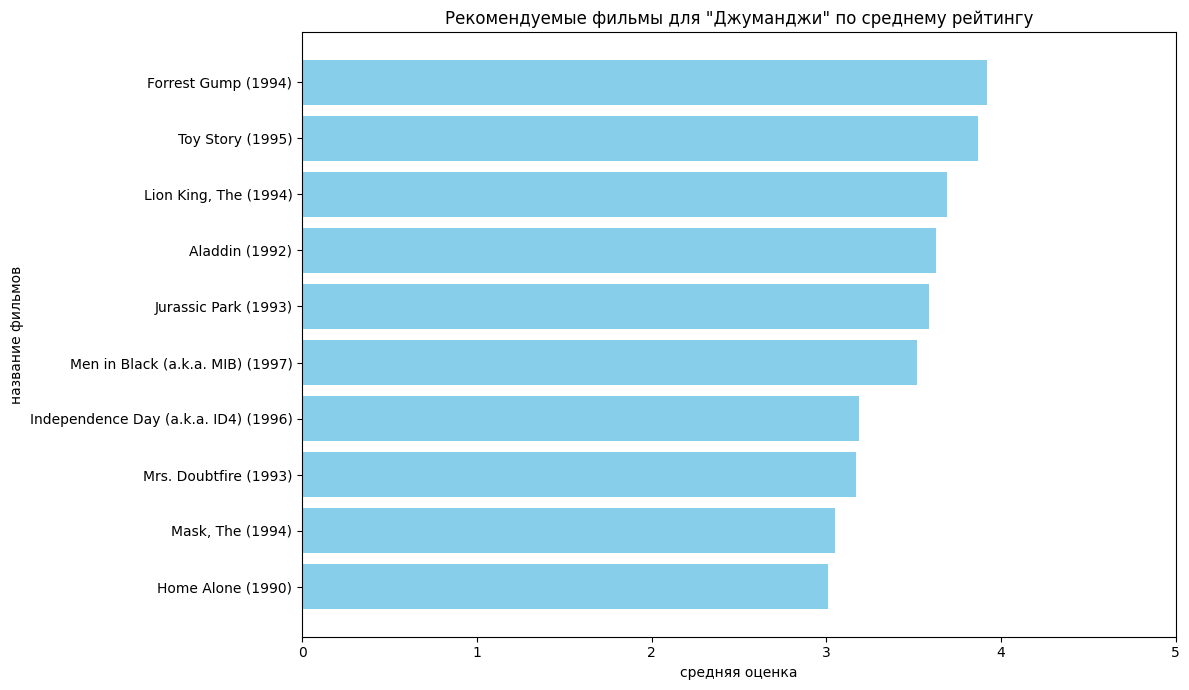

In [ ]:
import matplotlib.pyplot as plt

#@title Строим столбчатую диаграму на основе выходных данных по рекомендаций модели по фильму Джуманджи
# Данные, предоставленные пользователем
data = {
    'Title': [
        'Jurassic Park (1993)', 'Lion King, The (1994)', 'Mask, The (1994)',
        'Independence Day (a.k.a. ID4) (1996)', 'Home Alone (1990)', 'Mrs. Doubtfire (1993)',
        'Forrest Gump (1994)', 'Men in Black (a.k.a. MIB) (1997)', 'Toy Story (1995)',
        'Aladdin (1992)'
    ],
    'Distance': [
        0.35, 0.35, 0.36, 0.36, 0.37, 0.37, 0.37, 0.38, 0.38, 0.38
    ],
    'Average_Rating': [
        3.59, 3.69, 3.05, 3.19, 3.01, 3.17, 3.92, 3.52, 3.87, 3.63
    ]
}

# Создаем фрейм данных на основе предоставленных данных
recommended_movies_df = pd.DataFrame(data)

# Отсортируем фрейм данных по среднему значению для лучшей визуализации
recommended_movies_df = recommended_movies_df.sort_values(by='Average_Rating', ascending=False)

# Создайем столбчатую диаграмму
plt.figure(figsize=(12, 7))
plt.barh(recommended_movies_df['Title'], recommended_movies_df['Average_Rating'], color='skyblue')
plt.xlabel('средняя оценка')
plt.ylabel('название фильмов')
plt.title('Рекомендуемые фильмы для "Джуманджи" по среднему рейтингу')
plt.xlim(0, 5) # Предполагаем, что оценки даны по шкале от 0 до 5
plt.gca().invert_yaxis() # Перевернем ось y, чтобы получить самый высокий рейтинг вверху
plt.tight_layout()
plt.show()


# Выводы по анализу данных по модели рекомендаций фильмов


## Изучение принципов работы коллаборативной фильтрации (KNN)


### Объяснение принципов работы коллаборативной фильтрации (KNN) с косинусным сходством

1.  **Общий принцип работы коллаборативной фильтрации на основе элементов (Item-Item Collaborative Filtering)**:
    Коллаборативная фильтрация на основе элементов работает по принципу «люди, которым понравился X, также понравился Y». В контексте рекомендаций фильмов это означает, что если пользователь просмотрел и оценил фильм A, система будет искать другие фильмы, которые похожи на A, основываясь на том, как другие пользователи оценивали эти фильмы. Основная идея заключается в том, чтобы найти фильмы, которые имеют схожие паттерны оценок со стороны пользователей. То есть, если многие пользователи, высоко оценившие фильм A, также высоко оценили фильм B, то фильм B считается похожим на фильм A.

2.  **Использование алгоритма K-Nearest Neighbors (KNN)**:
    Алгоритм KNN в этом контексте используется для идентификации 'K' наиболее похожих фильмов на заданный фильм. Для каждого фильма, который мы хотим рекомендовать, KNN находит 'K' других фильмов (соседей), чьи векторы оценок максимально близки к вектору оценок исходного фильма. Близость (или сходство) этих фильмов определяется с помощью метрики расстояния, в данном случае — косинусного сходства.
    *   **Подготовка данных**: Сначала создается матрица, где строки представляют фильмы, а столбцы — пользователей (или наоборот, в зависимости от подхода), а значения в ячейках — это оценки, которые пользователи поставили фильмам. Если пользователь не оценил фильм, значение может быть нулевым или заполнено каким-либо средним значением.
    *   **Поиск соседей**: Когда пользователь запрашивает рекомендации для определенного фильма, система берет вектор оценок этого фильма из матрицы и сравнивает его со всеми остальными векторами фильмов в матрице, используя выбранную метрику сходства. KNN затем выбирает 'K' фильмов с наибольшим сходством (наименьшим расстоянием).

3.  **Косинусное сходство (Cosine Similarity)**:
    Косинусное сходство — это метрика, используемая для измерения сходства между двумя ненулевыми векторами в многомерном пространстве. Оно вычисляется как косинус угла между двумя векторами. Формула для косинусного сходства между двумя векторами A и B:
    
    `Cosine Similarity = (A · B) / (||A|| * ||B||)`
    
    Где:
    *   `A · B` — это скалярное произведение векторов A и B.
    *   `||A||` и `||B||` — это евклидовы нормы (длины) векторов A и B.
    
    В контексте рекомендаций фильмов:
    *   Каждый фильм представлен вектором, где каждое измерение соответствует оценке от конкретного пользователя.
    *   Косинусное сходство измеряет, насколько два вектора оценок фильмов указывают в одном направлении. Если пользователи оценивали два фильма очень схожим образом (например, все, кто любил фильм A, также любили фильм B), то векторы оценок этих фильмов будут почти параллельны, и угол между ними будет мал.
    *   **Угол между векторами**: Чем меньше угол между векторами, тем выше косинус угла (ближе к 1), и, следовательно, тем выше сходство. Большой угол (ближе к 90 градусам) означает низкое сходство (косинус ближе к 0), а угол в 180 градусов означает полную противоположность (косинус равен -1, что редко бывает в рейтингах).

4.  **Как более высокие значения косинусного сходства указывают на более похожие фильмы**:
    Значение косинусного сходства варьируется от -1 до 1:
    *   **1**: Означает, что векторы абсолютно совпадают по направлению (фильмы оценены абсолютно одинаково всеми пользователями).
    *   **0**: Означает, что векторы ортогональны (нет линейной зависимости), то есть нет сходства в шаблонах оценок.
    *   **-1**: Означает, что векторы указывают в противоположных направлениях (один фильм последовательно оценивается высоко, когда другой оценивается низко).
    
    Таким образом, чем ближе значение косинусного сходства к 1, тем более похожи фильмы с точки зрения общих пользовательских оценок. Модель KNN использует эту метрику для ранжирования потенциально рекомендуемых фильмов: фильмы с наивысшим косинусным сходством к целевому фильму будут считаться наиболее подходящими для рекомендации.

## Роль матрицы 'фильм-пользователь'


#### Объяснение концепции матрицы 'фильм-пользователь' и ее роли:

1.  **Концепция матрицы 'фильм-пользователь' в контексте коллаборативной фильтрации:**
    В рекомендательных системах, основанных на коллаборативной фильтрации по элементам (item-based collaborative filtering), центральное место занимает матрица, где строки представляют фильмы (элементы), а столбцы представляют пользователей. Каждая ячейка (i, j) этой матрицы содержит оценку (рейтинг), которую пользователь j поставил фильму i. Если пользователь не оценил фильм, значение в соответствующей ячейке обычно равно нулю (или NaN, если используется для расчетов, не включающих нули).

2.  **Создание `pivoted_df` из `filtered_ratings`:**
    Исходные данные об оценках пользователей (`filtered_ratings`) представлены в "длинном" формате, где каждая строка — это отдельная оценка (userId, movieId, rating). Для преобразования этих данных в матричную форму используется операция `pivot`. В данном случае, `pivoted_df` создается следующим образом:
    *   `userId` становится индексом (строками) DataFrame.
    *   `movieId` становится столбцами DataFrame.
    *   `rating` становится значениями в ячейках на пересечении пользователя и фильма.
    *   Значения `NaN` (для фильмов, которые пользователь не оценил) заполняются нулями с помощью `.fillna(0)`.

    Таким образом, `pivoted_df` представляет собой матрицу "пользователь-фильм", где строки — это пользователи, а столбцы — фильмы.

3.  **Транспонирование `pivoted_df` для создания `item_user_matrix`:**
    Модель `NearestNeighbors` (KNN), используемая здесь, рассчитывает сходство между строками входной матрицы. Для того чтобы найти похожие фильмы (а не похожих пользователей), нам нужно, чтобы каждый фильм был представлен как строка в матрице, а его "признаки" (в данном случае — оценки пользователей) были столбцами. Поэтому `pivoted_df` (пользователь x фильм) транспонируется (`.T.values`) для создания `item_user_matrix` (фильм x пользователь). Теперь каждая строка в `item_user_matrix` представляет собой вектор оценок одного фильма всеми пользователями. Это позволяет KNN эффективно вычислять сходство между фильмами.

4.  **Оптимизация хранения данных и вычислений с помощью `csr_matrix`:**
    Матрицы оценок обычно очень разрежены, то есть большинство фильмов не оценены большинством пользователей, и, следовательно, большинство ячеек содержат нули. Хранение такой матрицы в полном формате (как `pivoted_df`) требует очень много памяти и замедляет вычисления. `csr_matrix` (Compressed Sparse Row matrix) — это эффективный формат для хранения разреженных матриц, который хранит только ненулевые элементы, что значительно сокращает объем памяти и ускоряет операции. В данном случае, `item_user_matrix` создается как разреженная матрица CSR, что критически важно для работы с большими датасетами.

5.  **Использование `item_user_matrix` моделью KNN для расчета косинусного сходства:**
    Модель `NearestNeighbors` с метрикой `cosine` обучена на `item_user_matrix`. Когда мы запрашиваем рекомендации для конкретного фильма, модель делает следующее:
    *   Она берет вектор оценок этого фильма из `item_user_matrix`.
    *   Затем она сравнивает этот вектор со всеми остальными векторами фильмов в матрице, используя косинусное сходство.
    *   **Косинусное сходство** измеряет косинус угла между двумя векторами в многомерном пространстве. Значение, близкое к 1, указывает на высокое сходство (маленький угол), а значение, близкое к 0, указывает на низкое сходство (угол около 90 градусов). Расстояние (которое возвращает модель `NearestNeighbors` при `metric='cosine'`) вычисляется как `1 - cosine_similarity`.
    *   Фильмы с наименьшим расстоянием (то есть с наибольшим косинусным сходством) считаются наиболее похожими на исходный фильм и предлагаются в качестве рекомендаций. Это означает, что если пользователи, которым понравился один фильм, также склонны ставить высокие оценки другому фильму, эти два фильма будут считаться похожими.

### Влияние пороговых значений фильтрации `min_user_ratings` и `min_movie_ratings`

Параметры `min_user_ratings` и `min_movie_ratings` играют ключевую роль в подготовке данных для модели рекомендаций, основанной на коллаборативной фильтрации. Они определяют минимальное количество оценок, которое должен оставить пользователь, и минимальное количество оценок, которое должен получить фильм, чтобы быть включенным в обучающий набор данных. Эти пороговые значения оказывают существенное влияние на объем данных, качество рекомендаций, точность косинусного сходства и вычислительную нагрузку.

#### 1. Уменьшение объема данных и фокус на активных участниках

*   **`min_user_ratings` (минимальное количество оценок от пользователя):** Этот параметр отфильтровывает так называемых «холодных» пользователей или «случайных» пользователей, которые оставили очень мало оценок. Пользователи, оставившие небольшое количество оценок, могут не иметь достаточно данных, чтобы модель могла точно определить их предпочтения. Устанавливая порог, например, `min_user_ratings = 200`, мы гарантируем, что в модель попадают только те пользователи, которые являются достаточно активными и чьи предпочтения хорошо выражены.

    *Пример:* Если пользователь оценил только 5 фильмов, его вкусы могут быть неочевидны. Если же он оценил 200+ фильмов, его профиль становится гораздо более надежным для выявления паттернов. Это позволяет модели сосредоточиться на «активных участниках», чьи данные более значимы.

*   **`min_movie_ratings` (минимальное количество оценок для фильма):** Аналогично, этот параметр исключает фильмы, которые получили очень мало оценок. Фильмы с малым количеством оценок могут быть либо очень нишевыми, либо новыми, либо просто неинтересными большинству пользователей. Их включение может внести шум в модель, так как оценки нескольких пользователей могут быть нерепрезентативными для общей популярности или качества фильма. Устанавливая порог, например, `min_movie_ratings = 200`, мы включаем только «популярные» или достаточно оцененные фильмы.

    *Пример:* Фильм, который оценили 3 человека, может иметь среднюю оценку 5.0, но это не означает его всеобщей популярности. Фильм, оцененный 200+ раз со средней оценкой 4.0, является гораздо более надежным кандидатом для рекомендаций.

#### 2. Влияние на качество рекомендаций и точность косинусного сходства

*   **Улучшение качества рекомендаций:** Отфильтровывая неактивных пользователей и непопулярные фильмы, мы удаляем разреженные и потенциально неточные данные. Модель обучается на более плотном и релевантном наборе данных, что позволяет ей находить более сильные и осмысленные взаимосвязи между пользователями и фильмами. Это приводит к более точным и релевантным рекомендациям.

*   **Повышение точности косинусного сходства:** Косинусное сходство измеряет угол между векторами оценок. Если векторы очень разрежены (то есть содержат много нулей из-за отсутствия оценок), расчет сходства может быть менее надежным. Фильтрация гарантирует, что векторы оценок пользователей и фильмов, используемые для расчета косинусного сходства, содержат достаточное количество ненулевых значений, что делает меру сходства более устойчивой и информативной.

    *Пример:* Если два пользователя оценили только один общий фильм, их косинусное сходство может быть высоким, но это случайное совпадение. Если они оценили 100 общих фильмов, и их оценки схожи, тогда косинусное сходство будет гораздо более надежным показателем их похожих вкусов.

#### 3. Снижение вычислительной нагрузки и улучшение производительности

*   **Оптимизация производительности:** Матрица оценок (например, `item_user_matrix` в данном случае) может быть очень большой и разреженной. Фильтрация значительно уменьшает размер этой матрицы, исключая строки (фильмы) и столбцы (пользователей), которые не соответствуют пороговым значениям. Меньшая матрица требует меньше памяти и значительно сокращает время, необходимое для обучения модели (`cf_knn_model.fit()`) и выполнения запросов (`cf_model.kneighbors()`).

    *Пример:* Исходный набор данных `ratings_df` содержит более 20 миллионов оценок. После фильтрации количество оценок сократилось до 11.9 миллиона, что значительно уменьшает объем данных, обрабатываемых моделью, делая вычисления быстрее и эффективнее.

#### Заключение

Таким образом, `min_user_ratings` и `min_movie_ratings` являются важными параметрами для предварительной обработки данных в системах рекомендаций. Они помогают сосредоточиться на самых информативных данных от активных пользователей и популярных фильмов, улучшая качество и релевантность рекомендаций, повышая точность метрик сходства и существенно снижая вычислительные затраты, делая модель более масштабируемой и эффективной.

## Интерпретация метрики 'Distance'

Объяснить, что означает 'Distance' (косинусное расстояние) в рекомендациях, полученных от модели KNN, и как более низкие значения указывают на более высокое сходство между фильмами на основе оценок.

### Объяснение 'Distance' (Косинусное расстояние) в рекомендациях KNN

В контексте нашей системы рекомендаций на основе модели K-ближайших соседей (KNN), метрика **'Distance'** относится к **косинусному расстоянию** (Cosine Distance). Эта метрика используется для измерения сходства между двумя векторами в многомерном пространстве. В нашем случае эти векторы представляют фильмы, а их измерениями являются оценки, поставленные пользователями.

1.  **Определение косинусного расстояния и его взаимосвязь с косинусным сходством:**
    *   **Косинусное сходство (Cosine Similarity)** измеряет косинус угла между двумя ненулевыми векторами. Значение косинусного сходства варьируется от -1 до 1. Значение 1 означает, что векторы указывают в одном направлении (полное сходство), 0 означает ортогональность (отсутствие линейной зависимости), а -1 означает, что они указывают в противоположных направлениях (полное несходство).
    *   В рекомендательных системах, где оценки обычно положительны (например, от 1 до 5), косинусное сходство чаще всего находится в диапазоне от 0 до 1.
    *   **Косинусное расстояние** вычисляется как **1 - Косинусное сходство**. Таким образом, если косинусное сходство близко к 1 (высокое сходство), косинусное расстояние будет близко к 0. И наоборот, если косинусное сходство близко к 0 (низкое сходство), косинусное расстояние будет близко к 1.

2.  **Как модель KNN использует эту метрику для ранжирования рекомендаций:**
    *   Модель KNN (NearestNeighbors) обучена на **матрице "элемент-пользователь"**, где строки представляют фильмы, а столбцы — пользователей. Значения в ячейках матрицы — это оценки, которые пользователи поставили фильмам.
    *   Когда вы запрашиваете рекомендации для конкретного фильма (например, "Аватар"), модель находит вектор оценок этого фильма в матрице.
    *   Затем модель KNN вычисляет косинусное расстояние между вектором оценок "Аватара" и векторами оценок всех остальных фильмов в матрице.
    *   Фильмы с наименьшим косинусным расстоянием к "Аватару" считаются "ближайшими соседями" — то есть фильмами, которые пользователи оценивали очень похожим образом.
    *   Эти "ближайшие соседи" и являются рекомендациями, поскольку предполагается, что если пользователю понравился "Аватар", то ему, скорее всего, понравятся и фильмы, которые другие пользователи оценивали аналогично "Аватару".

3.  **Интерпретация: более низкое значение 'Distance' означает более высокое сходство:**
    *   Чем меньше значение 'Distance' (косинусного расстояния), тем выше косинусное сходство между двумя фильмами.
    *   **Низкое 'Distance' (близко к 0)** означает, что паттерны оценок этих фильмов очень похожи. Это может указывать на то, что пользователи, которым понравился один фильм, скорее всего, также понравился и другой, и наоборот.
    *   **Высокое 'Distance' (близко к 1)** означает, что паттерны оценок фильмов сильно различаются, что говорит о низком сходстве между ними.
    *   Таким образом, в списке рекомендаций фильмы с меньшими значениями 'Distance' являются более сильными рекомендациями, поскольку они наиболее похожи на исходный фильм по мнению пользователей.

4.  **Примеры из выходных данных модели:**

    *   **Рекомендации для фильма "Аватар":**

        | Title                       | Distance | Average_Rating |
        | :-------------------------- | :------- | :------------- |
        | Inception (2010)            | 0.26     | 4.11           |
        | District 9 (2009)           | 0.31     | 3.85           |
        | Dark Knight, The (2008)     | 0.31     | 4.17           |

        Здесь мы видим, что фильм **"Inception (2010)"** имеет самое низкое расстояние (0.26) до "Аватара". Это означает, что из всех рекомендованных фильмов пользователи оценивали "Начало" наиболее схожим образом с "Аватаром", что делает его самой сильной рекомендацией. "District 9 (2009)" и "Dark Knight, The (2008)" имеют одинаковое расстояние (0.31), что указывает на чуть меньшее, но все еще высокое сходство.

    *   **Рекомендации для фильма "Джуманджи":**

        | Title                                | Distance | Average_Rating |
        | :----------------------------------- | :------- | :------------- |
        | Jurassic Park (1993)                 | 0.35     | 3.59           |
        | Lion King, The (1994)                | 0.35     | 3.69           |
        | Mask, The (1994)                     | 0.36     | 3.05           |

        Для "Джуманджи" **"Jurassic Park (1993)"** и **"Lion King, The (1994)"** имеют самое низкое расстояние (0.35), что указывает на их наибольшее сходство с "Джуманджи" с точки зрения пользовательских оценок. "Mask, The (1994)" имеет чуть большее расстояние (0.36), что говорит о немного меньшем, но все же значительном сходстве.

Таким образом, 'Distance' является ключевой метрикой для понимания, насколько два фильма похожи на основе коллективных предпочтений пользователей, и позволяет модели KNN эффективно ранжировать рекомендации.

## Значение 'Average_Rating' в рекомендациях


Хочу указать что средняя оценка фильма ('Average_Rating') не используется самой моделью KNN для определения сходства, но является важным описательным признаком, который помогает пользователям оценить качество рекомендованных фильмов.


## ## Резюме:

### Основные выводы из анализа данных по модели

* ** Модель KNN и косинусоидальное сходство **: Модель K-ближайших соседей (KNN) использует коллаборативную фильтрацию на основе элементов, выявляя похожие фильмы на основе того, как их оценивают пользователи. Косинусное сходство, рассчитываемое как косинус угла между двумя векторами рейтинга фильмов, является основным показателем для определения сходства. Значение косинусного сходства, близкое к 1, указывает на более высокое сходство между фильмами.
* ** Роль матрицы "Элемент-пользователь" **: Матрица "item_user_matrix" формируется путем преобразования "pivoted_df" (изначально это матрица "пользователь-элемент", где строками являются пользователи, а столбцами - фильмы). Это преобразование гарантирует, что фильмы будут представлены в виде строк, а их оценки разными пользователями - в виде столбцов, что позволяет модели KNN эффективно вычислять сходство между фильмами. Использование csr_matrix оптимизирует хранение и вычисления для этой, как правило, разреженной матрицы.
* **Влияние пороговых значений фильтрации**:
    * `min_user_ratings" отфильтровывает пользователей с недостаточным рейтингом (например, менее 200), фокусируя модель на активных пользователях с более надежными данными о предпочтениях.
    * `min_movie_ratings" отфильтровывает фильмы со слишком низким рейтингом (например, менее 200), обеспечивая, чтобы рекомендации основывались на фильмах с высоким рейтингом и уменьшали количество помех от нерепрезентативных данных.
    * Эти фильтры значительно сокращают объем данных (например, с более чем 20 миллионов до 11,9 миллионов оценок), повышают точность определения косинусоидального сходства за счет обеспечения более плотных векторов оценок и повышают эффективность вычислений.
* ** Интерпретация "Расстояния" **: Показатель "Расстояния" в рекомендациях KNN представляет собой косинусное расстояние, которое рассчитывается как `1 - косинусное сходство`. Следовательно, меньшее значение "Расстояния" указывает на более высокое косинусное сходство и, следовательно, на большее сходство между фильмами, основанное на общих оценках пользователей. Например, в рекомендациях к фильму "Аватар", "Начало (2010)", расстояние между которыми равно 0,26, означает, что он является наиболее похожим из рекомендованных фильмов.

### Идеи или следующие шаги

* ** Уточнение пороговых значений фильтрации **: Параметры "min_user_ratings" и "min_movie_ratings" имеют решающее значение для обеспечения баланса плотности и охвата данных. Дальнейшие эксперименты с этими пороговыми значениями могли бы оптимизировать качество рекомендаций в зависимости от охвата товаров и пользователей.
* ** Изучение гибридных моделей **: В то время как KNN предоставляет ценные рекомендации, основанные на элементах, его сочетание с другими рекомендательными методами (например, фильтрация на основе контента или матричная факторизация) может решить проблемы с запуском новых фильмов / пользователей и потенциально привести к получению более разнообразных и точных рекомендаций.

